# Main Code for Project

## Part 1: Data Preparation

Loads play-by-play CSVs from `hawkeye/play_by_play/`, filters valid trajectories, mirrors Ad-court x-coordinates, builds `(N, 3, 6)` sequences, scales (train-only fit), and saves `train_data.pt` / `val_data.pt` / `test_data.pt` (80% / 10% / 10%, stratified).

You can download the data by running `git clone https://github.com/ryurko/hawkeye.git`.

In [19]:
import pandas as pd
import numpy as np
import glob
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load all CSVs into one DataFrame
path = 'hawkeye/play_by_play'
all_files = glob.glob(path + "/*.csv")

df_list = []
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    df_list.append(df)

master_df = pd.concat(df_list, axis=0, ignore_index=True)
print(f"Total raw serves loaded: {len(master_df)}")

Total raw serves loaded: 195164


In [20]:
import pickle

# ryurko/hawkeye column names (see hawkeye/data_dictionary.md)
HIT = ['x_ball_serve_impact', 'y_ball_serve_impact', 'z_ball_serve_impact']
NET = ['x_net_serve', 'y_net_serve', 'z_net_serve']
BOUNCE = ['x_serve_bounce', 'y_serve_bounce', 'z_serve_bounce']
COORD_COLS = HIT + NET + BOUNCE

# 1. Filter: tracking available, complete milestones, Flat/Kick/Slice only
master_df = master_df[master_df['is_track_avail'] == True].copy()
master_df = master_df.dropna(subset=COORD_COLS + ['serve_type'])
master_df = master_df[master_df['serve_type'].isin(['Flat', 'Kick', 'Slice'])]

print(f"Serves after filtering: {len(master_df)}")
print(master_df['serve_type'].value_counts())

label_mapping = {'Flat': 0, 'Kick': 1, 'Slice': 2}
labels = master_df['serve_type'].map(label_mapping).values

# 2. Mirror lateral x for Ad court (normalize trajectory geometry)
ad_mask = master_df['court_side'] == 'AdCourt'
for col in ['x_ball_serve_impact', 'x_net_serve', 'x_serve_bounce']:
    master_df.loc[ad_mask, col] *= -1

# 3. Build sequences: (N, 3, 6) — hit padded with zero deltas at step 1
hit = master_df[HIT].to_numpy(dtype=np.float64)
net = master_df[NET].to_numpy(dtype=np.float64)
bounce = master_df[BOUNCE].to_numpy(dtype=np.float64)

delta_hit_to_net = net - hit
delta_net_to_bounce = bounce - net

zeros = np.zeros((len(master_df), 3), dtype=np.float64)
node_hit = np.concatenate([hit, zeros], axis=1)
node_net = np.concatenate([net, delta_hit_to_net], axis=1)
node_bounce = np.concatenate([bounce, delta_net_to_bounce], axis=1)

X = np.stack([node_hit, node_net, node_bounce], axis=1)
print(f"X shape: {X.shape}")

# 4. Train / validation / test split (80% / 10% / 10%), stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 5. Standardize (fit scaler on train only)
n_train, time_steps, n_features = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, n_features))

def scale_split(arr):
    n, t, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, t, f)

X_train_scaled = scale_split(X_train)
X_val_scaled = scale_split(X_val)
X_test_scaled = scale_split(X_test)

# 6. PyTorch tensors and save for Phase 2
tensor_X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.long)
tensor_X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.long)
tensor_X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.long)

torch.save((tensor_X_train, tensor_y_train), 'train_data.pt')
torch.save((tensor_X_val, tensor_y_val), 'val_data.pt')
torch.save((tensor_X_test, tensor_y_test), 'test_data.pt')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

inverse_label = {0: 'Flat', 1: 'Kick', 2: 'Slice'}
example_idx = 0  # first training sample (for inspection cell below)
example_sample = X_train_scaled[example_idx]
example_label = int(y_train[example_idx])

print("Phase 1 complete.")
print(f"Train: {tensor_X_train.shape}, labels: {np.bincount(y_train)}")
print(f"Val:   {tensor_X_val.shape}, labels: {np.bincount(y_val)}")
print(f"Test:  {tensor_X_test.shape}, labels: {np.bincount(y_test)}")

Serves after filtering: 74226
serve_type
Flat     34765
Slice    32224
Kick      7237
Name: count, dtype: int64
X shape: (74226, 3, 6)
Phase 1 complete.
Train: torch.Size([59380, 3, 6]), labels: [27812  5789 25779]
Val:   torch.Size([7423, 3, 6]), labels: [3476  724 3223]
Test:  torch.Size([7423, 3, 6]), labels: [3477  724 3222]


In [21]:
# One example row: shape (3 timesteps, 6 features) — scaled (as fed to the LSTM)
FEATURE_NAMES = ['x', 'y', 'z', 'delta_x', 'delta_y', 'delta_z']
STEP_NAMES = ['hit', 'net', 'bounce']

example_df = pd.DataFrame(
    example_sample,
    index=STEP_NAMES,
    columns=FEATURE_NAMES,
)
print(f"Label: {example_label} ({inverse_label[example_label]})")
print(f"Tensor shape for one serve: {example_sample.shape}  (3 steps × 6 features)\n")
display(example_df.round(4))

# Same serve before scaling (raw coordinates + deltas)
raw_example = X_train[example_idx]
raw_df = pd.DataFrame(raw_example, index=STEP_NAMES, columns=FEATURE_NAMES)
print("Same serve — raw (unscaled) values:")
display(raw_df.round(4))

Label: 2 (Slice)
Tensor shape for one serve: (3, 6)  (3 steps × 6 features)



,x,y,z,delta_x,delta_y,delta_z
hit,-1.5668,-0.7500,1.0484,0.0001,-0.0003,1.3305
net,0.0001,0.2778,-0.2513,1.5670,1.2016,-0.8100
bounce,0.6612,0.5956,-1.1548,0.6612,0.3713,-0.1573


Same serve — raw (unscaled) values:


,x,y,z,delta_x,delta_y,delta_z
hit,-11.478,-1.326,2.516,0.000,0.000,0.000
net,-0.000,0.495,1.050,11.478,1.821,-1.466
bounce,4.843,1.058,0.031,4.843,0.563,-1.019


### Trajectory sanity check (3D)

Plot hit → net → bounce using the first three features `(x, y, z)` at each step. **Scaled** space is what the LSTM sees; **raw** space is what you use to judge physics (arc over net, bounce in box). Wild zig-zags in raw usually mean a bug in mirroring or step order; zig-zags only in scaled are often normal (per-feature standardization).

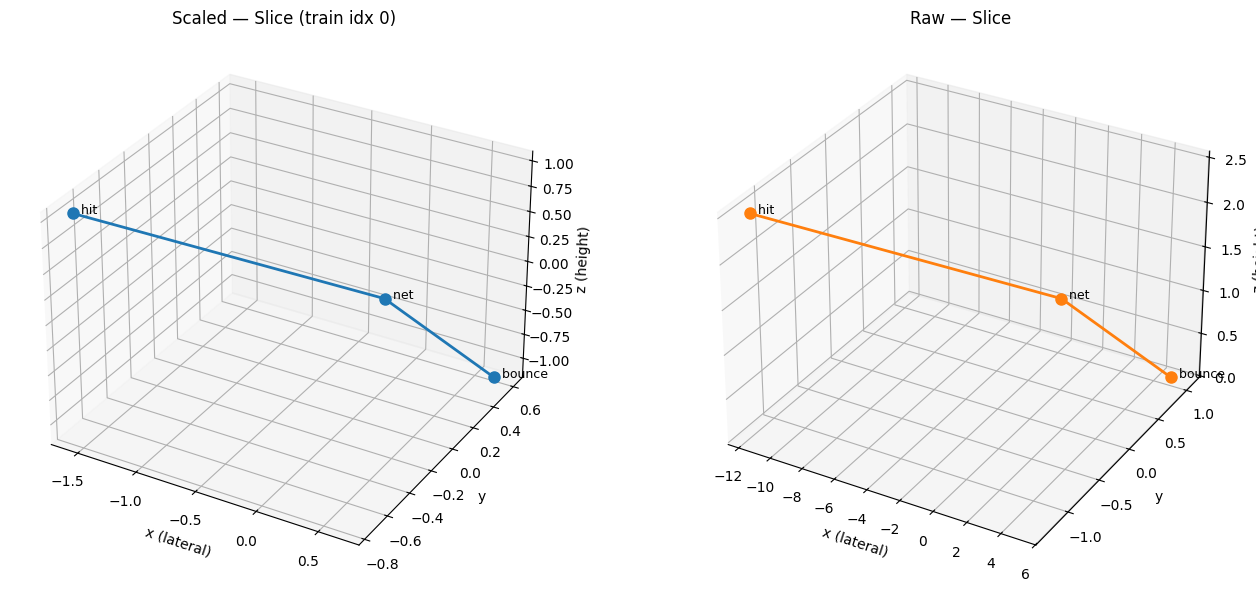

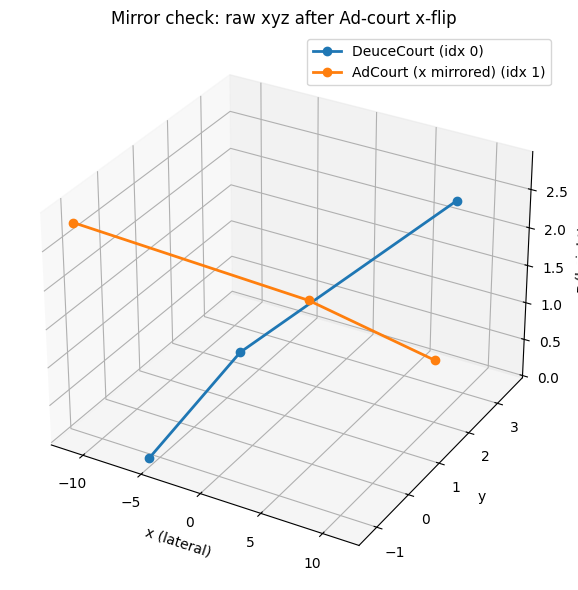

Raw: expect hit → net (x≈0 at net) → bounce in one smooth arc.
Scaled: LSTM input — shape can look odd; use raw plot to verify geometry.


In [22]:
import matplotlib.pyplot as plt

def plot_serve_path(seq, ax, title, color='C0', annotate=True):
    """seq: (3, 6) — plot xyz at hit, net, bounce."""
    pts = seq[:, :3]
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], 'o-', color=color, linewidth=2, markersize=8)
    if annotate:
        for name, p in zip(['hit', 'net', 'bounce'], pts):
            ax.text(p[0], p[1], p[2], f'  {name}', fontsize=9)
    ax.set_xlabel('x (lateral)')
    ax.set_ylabel('y')
    ax.set_zlabel('z (height)')
    ax.set_title(title)

# --- Single serve (training example) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})
plot_serve_path(
    example_sample,
    axes[0],
    f'Scaled — {inverse_label[example_label]} (train idx {example_idx})',
    color='C0',
)
plot_serve_path(
    X_train[example_idx],
    axes[1],
    f'Raw — {inverse_label[example_label]}',
    color='C1',
)
plt.tight_layout()
plt.show()

# --- Ad-court mirror check: one Deuce vs one Ad serve (raw, after x-flip) ---
deuce_pos = int(np.flatnonzero(master_df['court_side'].values == 'DeuceCourt')[0])
ad_pos = int(np.flatnonzero(master_df['court_side'].values == 'AdCourt')[0])

fig2 = plt.figure(figsize=(7, 6))
ax2 = fig2.add_subplot(111, projection='3d')
for pos, label, color in [
    (deuce_pos, 'DeuceCourt', 'C0'),
    (ad_pos, 'AdCourt (x mirrored)', 'C1'),
]:
    pts = X[pos, :, :3]
    ax2.plot(pts[:, 0], pts[:, 1], pts[:, 2], 'o-', color=color, linewidth=2, label=f'{label} (idx {pos})')
ax2.set_xlabel('x (lateral)')
ax2.set_ylabel('y')
ax2.set_zlabel('z (height)')
ax2.legend()
ax2.set_title('Mirror check: raw xyz after Ad-court x-flip')
plt.tight_layout()
plt.show()

print('Raw: expect hit → net (x≈0 at net) → bounce in one smooth arc.')
print('Scaled: LSTM input — shape can look odd; use raw plot to verify geometry.')

## Part 2: Model (`model.py`)

Many-to-one **LSTM**: sequence `(batch, 3, 6)` → final hidden state → linear head → 3-class logits (Flat / Kick / Slice). Training uses `CrossEntropyLoss` on logits (softmax is inside the loss).

In [23]:
from model import CLASS_NAMES, NUM_CLASSES, build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, y_train = torch.load('train_data.pt', weights_only=True)
X_val, y_val = torch.load('val_data.pt', weights_only=True)
X_test, y_test = torch.load('test_data.pt', weights_only=True)

model = build_model(hidden_size=128, num_layers=2, dropout=0.2, device=device)

print(model)
print(f"Device: {device}")
print(f"Train: {tuple(X_train.shape)}, Val: {tuple(X_val.shape)}, Test: {tuple(X_test.shape)}")
print(f"Classes: {CLASS_NAMES}")

ServeLSTM(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=3, bias=True)
  )
)
Device: cuda
Train: (59380, 3, 6), Val: (7423, 3, 6), Test: (7423, 3, 6)
Classes: ('Flat', 'Kick', 'Slice')


## Phase 3: Hyperparameter tuning (optional)

Grid-search over the knobs below with fewer epochs (`SEARCH_EPOCHS`) to rank configs by **validation accuracy**, then train the winner for full `EPOCHS` in the next cell.

Set `RUN_GRID_SEARCH = False` to skip and use `MANUAL_PARAMS` instead.

In [34]:
import importlib
import torch
import train as train_module
importlib.reload(train_module)
from train import tune_hyperparameters

# Imbalance handling
USE_DOWNSAMPLING = False   # mutually exclusive with class-weighted loss
USE_CLASS_WEIGHTS = False  # ignored when MANUAL_CLASS_WEIGHTS is set

# Manual loss weights [Flat, Kick, Slice] — higher Kick => stronger penalty for missing Kick
# Auto from train counts (~28k / ~5.8k / ~26k): Flat≈0.44, Kick≈2.09, Slice≈0.47
from train import class_weights as compute_class_weights

_y_ref = torch.load("train_data.pt", weights_only=True)[1]
_auto = compute_class_weights(_y_ref)
print("Auto class weights:", dict(zip(["Flat", "Kick", "Slice"], [round(w, 3) for w in _auto.tolist()])))

MANUAL_CLASS_WEIGHTS = [0.436, 1.394, 0.47]  # bump Kick above auto (~2.1); tune 4–8 if needed

RUN_GRID_SEARCH = False  # set False to skip search and use MANUAL_PARAMS

# Edit lists to try more/fewer combinations (cartesian product)
SEARCH_GRID = {
    "lr": [1e-3, 8e-4, 5e-4],          # keep
    "hidden_size": [96, 128, 192],     # tighter than [64,128,256]
    "dropout": [0.15, 0.3],            # slightly wider regularization spread
    "batch_size": [256, 512],          # keep
    "use_layernorm": [False, True],    # keep
    "bidirectional": [False, True],    # keep
}

SEARCH_EPOCHS = 12   # slightly shorter so 144 trials finishes sooner
SEARCH_PATIENCE = 3

MANUAL_PARAMS = dict(
    lr=2e-3,   # aggressive start; scheduler lowers on val-loss plateau
    hidden_size=256,
    num_layers=2,
    dropout=0.3,
    batch_size=128,
    weight_decay=0,
    use_layernorm=True,
    bidirectional=True,
)

n_combos = 1
for v in SEARCH_GRID.values():
    n_combos *= len(v)
print(f"Grid size: {n_combos} trials × {SEARCH_EPOCHS} epochs each")

if RUN_GRID_SEARCH:
    tune_results = tune_hyperparameters(
        SEARCH_GRID,
        search_epochs=SEARCH_EPOCHS,
        patience=SEARCH_PATIENCE,
        use_class_weights=USE_CLASS_WEIGHTS,
        use_downsampling=USE_DOWNSAMPLING,
        manual_class_weights=MANUAL_CLASS_WEIGHTS,
    )
    display(tune_results)
    param_cols = list(SEARCH_GRID.keys())
    best_params = tune_results.iloc[0][param_cols].to_dict()
    print("\nBest params for final training:", best_params)
else:
    tune_results = None
    best_params = MANUAL_PARAMS.copy()
    print("Using manual params:", best_params)

Auto class weights: {'Flat': 0.436, 'Kick': 2.094, 'Slice': 0.47}
Grid size: 144 trials × 12 epochs each
Using manual params: {'lr': 0.002, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 128, 'weight_decay': 0, 'use_layernorm': True, 'bidirectional': True}


In [12]:
# Stage-2 refinement (run after stage-1 tuning cell)
# Builds a small local grid around stage-1 best params.

from train import tune_hyperparameters

def _clip(v, low, high):
    return max(low, min(high, v))

base = best_params.copy()

# Local neighborhoods around stage-1 best
lr0 = float(base["lr"])
hs0 = int(base["hidden_size"])
do0 = float(base["dropout"])

# Keep this compact (typically 8-16 trials)
REFINE_GRID = {
    "lr": sorted({round(lr0 * 0.8, 6), lr0, round(lr0 * 1.2, 6)}),
    "hidden_size": sorted({
        int(_clip(round(hs0 * 0.75 / 32) * 32, 64, 256)),
        hs0,
        int(_clip(round(hs0 * 1.25 / 32) * 32, 64, 256)),
    }),
    "dropout": sorted({round(_clip(do0 - 0.1, 0.1, 0.5), 2), do0, round(_clip(do0 + 0.1, 0.1, 0.5), 2)}),
    # Add two knobs not searched in stage-1 coarse sweep
    "num_layers": [1, 2],
    "weight_decay": [0.0, 1e-5],
    # Hold these fixed to stage-1 winner
    "batch_size": [int(base["batch_size"])],
    "use_layernorm": [bool(base["use_layernorm"])],
    "bidirectional": [bool(base["bidirectional"])],
}

# Optional: prune duplicates in each list
for k, vals in REFINE_GRID.items():
    REFINE_GRID[k] = list(dict.fromkeys(vals))

# Keep runtime manageable
REFINE_EPOCHS = 12
REFINE_PATIENCE = 4

n_refine = 1
for v in REFINE_GRID.values():
    n_refine *= len(v)
print(f"Stage-2 grid size: {n_refine} trials × {REFINE_EPOCHS} epochs each")
print("Base params:", base)

refine_results = tune_hyperparameters(
    REFINE_GRID,
    search_epochs=REFINE_EPOCHS,
    patience=REFINE_PATIENCE,
    use_class_weights=USE_CLASS_WEIGHTS,
    use_downsampling=USE_DOWNSAMPLING,
    manual_class_weights=MANUAL_CLASS_WEIGHTS,
)
display(refine_results)

param_cols = list(REFINE_GRID.keys())
best_refined_params = refine_results.iloc[0][param_cols].to_dict()
print("\nBest refined params:", best_refined_params)

Stage-2 grid size: 72 trials × 12 epochs each
Base params: {'lr': 0.0008, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 128, 'weight_decay': 0, 'use_layernorm': True, 'bidirectional': True}

=== Trial 1/72: {'lr': 0.00064, 'hidden_size': 192, 'dropout': 0.2, 'num_layers': 1, 'weight_decay': 0.0, 'batch_size': 128, 'use_layernorm': True, 'bidirectional': True} ===
Loss class weights (manual): {'Flat': 1.0, 'Kick': 8.0, 'Slice': 1.0}


KeyboardInterrupt: 

### Final training

Trains with `best_params` from the cell above (or `MANUAL_PARAMS` if search was skipped).

In [35]:
import importlib
import train as train_module
importlib.reload(train_module)
from train import run_training

EPOCHS = 35
FINAL_PATIENCE = 5

# Start with a higher lr; ReduceLROnPlateau cuts it when val loss stops improving
USE_LR_SCHEDULER = True
LR_SCHEDULER_PATIENCE = 2   # epochs without val-loss improvement before reducing lr
LR_SCHEDULER_FACTOR = 0.5   # new_lr = lr * factor on each plateau

history = run_training(
    epochs=EPOCHS,
    patience=FINAL_PATIENCE,
    use_class_weights=USE_CLASS_WEIGHTS,
    use_downsampling=USE_DOWNSAMPLING,
    manual_class_weights=MANUAL_CLASS_WEIGHTS,
    use_lr_scheduler=USE_LR_SCHEDULER,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    **best_params,
)

model = history["model"]
device = history["device"]
print(f"Final best val acc: {history['best_val_acc']:.3f}")

Loss class weights (manual): {'Flat': 0.436, 'Kick': 1.394, 'Slice': 0.47}
LR scheduler: ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-06)
Epoch 01/35 | train loss 1.1017 acc 0.455 | val loss 1.0647 acc 0.471 | lr 2.00e-03
Epoch 02/35 | train loss 1.0214 acc 0.499 | val loss 0.9597 acc 0.560 | lr 2.00e-03
Epoch 03/35 | train loss 0.9443 acc 0.559 | val loss 0.9464 acc 0.509 | lr 2.00e-03
Epoch 04/35 | train loss 0.9170 acc 0.578 | val loss 0.9039 acc 0.568 | lr 2.00e-03
Epoch 05/35 | train loss 0.9029 acc 0.590 | val loss 0.9151 acc 0.607 | lr 2.00e-03
Epoch 06/35 | train loss 0.8767 acc 0.617 | val loss 0.8507 acc 0.648 | lr 2.00e-03
Epoch 07/35 | train loss 0.8556 acc 0.634 | val loss 0.8418 acc 0.627 | lr 2.00e-03
Epoch 08/35 | train loss 0.8418 acc 0.639 | val loss 0.8770 acc 0.618 | lr 2.00e-03
Epoch 09/35 | train loss 0.8324 acc 0.643 | val loss 0.8368 acc 0.625 | lr 2.00e-03
Epoch 10/35 | train loss 0.8267 acc 0.647 | val loss 0.8176 acc 0.645 | lr 2.00e-03
Epoch 11/35 | t

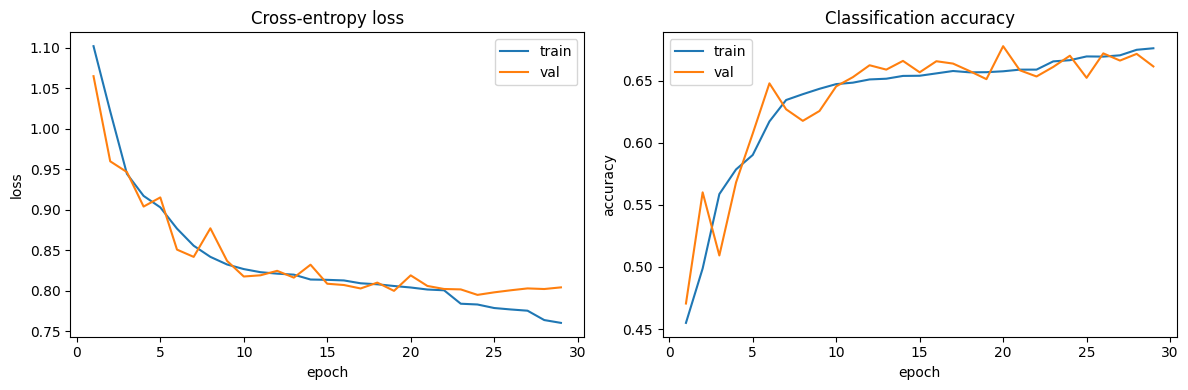

In [38]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs_ran, history["train_loss"], label="train")
ax[0].plot(epochs_ran, history["val_loss"], label="val")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Cross-entropy loss")
ax[0].legend()

ax[1].plot(epochs_ran, history["train_acc"], label="train")
ax[1].plot(epochs_ran, history["val_acc"], label="val")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Classification accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Test set evaluation

Test loss: 0.7385  |  Test accuracy: 0.676

              precision    recall  f1-score   support

        Flat       0.80      0.66      0.72      3477
        Kick       0.32      0.57      0.41       724
       Slice       0.71      0.72      0.71      3222

    accuracy                           0.68      7423
   macro avg       0.61      0.65      0.62      7423
weighted avg       0.71      0.68      0.69      7423



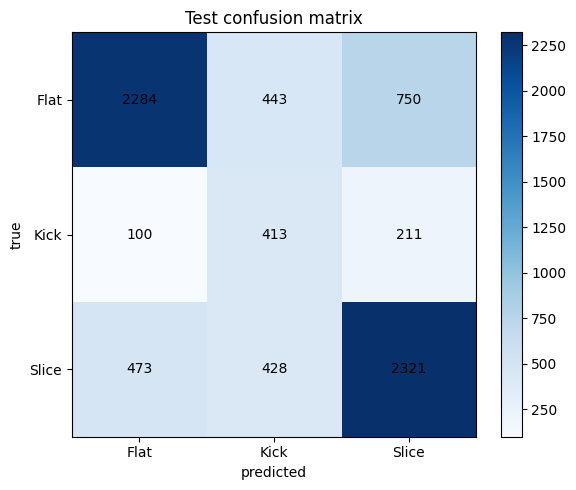

In [39]:
from torch.utils.data import DataLoader, TensorDataset
from train import evaluate, predict_all
from sklearn.metrics import classification_report, confusion_matrix

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=512,
    shuffle=False,
)

# Unweighted loss on the natural test distribution
criterion = torch.nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
y_pred, y_true = predict_all(model, test_loader, device)

print(f"Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.3f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES)
ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Test confusion matrix")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Phase 4: Data Analysis

Exploratory analysis of Hawk-Eye serve trajectories and model behavior. Rebuilds the filtered dataset from Part 1 (no need to re-run training). Charts focus on **class imbalance**, **physics differences** between Flat / Kick / Slice, and **where the classifier struggles**.

In [40]:
import glob
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

try:
    import torch
    from model import CLASS_NAMES, NUM_CLASSES
    from train import predict_all
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

plt.style.use("ggplot")
PALETTE = {"Flat": "#4C72B0", "Kick": "#DD8452", "Slice": "#55A868"}
LABEL_MAP = {"Flat": 0, "Kick": 1, "Slice": 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}

HIT = ["x_ball_serve_impact", "y_ball_serve_impact", "z_ball_serve_impact"]
NET = ["x_net_serve", "y_net_serve", "z_net_serve"]
BOUNCE = ["x_serve_bounce", "y_serve_bounce", "z_serve_bounce"]
COORD_COLS = HIT + NET + BOUNCE

# --- Load & filter (same rules as Part 1) ---
path = "hawkeye/play_by_play"
dfs = [pd.read_csv(f) for f in glob.glob(path + "/*.csv")]
raw_df = pd.concat(dfs, ignore_index=True)

analysis_df = raw_df[raw_df["is_track_avail"] == True].copy()
analysis_df = analysis_df.dropna(subset=COORD_COLS + ["serve_type"])
analysis_df = analysis_df[analysis_df["serve_type"].isin(["Flat", "Kick", "Slice"])].copy()

ad_mask = analysis_df["court_side"] == "AdCourt"
for col in ["x_ball_serve_impact", "x_net_serve", "x_serve_bounce"]:
    analysis_df.loc[ad_mask, col] *= -1

def parse_speed_kph(val):
    if pd.isna(val):
        return np.nan
    s = str(val).upper().replace("KPH", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

analysis_df["speed_kph"] = analysis_df["serve_speed_kph"].map(parse_speed_kph)

# Physics-derived features (raw meters, after Ad-court mirror)
hit = analysis_df[HIT].to_numpy()
net = analysis_df[NET].to_numpy()
bounce = analysis_df[BOUNCE].to_numpy()

analysis_df["dist_hit_net_m"] = np.linalg.norm(net - hit, axis=1)
analysis_df["dist_net_bounce_m"] = np.linalg.norm(bounce - net, axis=1)
analysis_df["net_height_m"] = net[:, 2]
analysis_df["net_lateral_m"] = net[:, 1]
analysis_df["bounce_lateral_m"] = bounce[:, 1]
analysis_df["hit_height_m"] = hit[:, 2]
analysis_df["apex_proxy_m"] = np.maximum(np.maximum(hit[:, 2], net[:, 2]), bounce[:, 2])
analysis_df["vertical_drop_hit_to_net_m"] = hit[:, 2] - net[:, 2]
analysis_df["lateral_swing_m"] = bounce[:, 1] - hit[:, 1]

# Same stratified split indices as Part 1 (for linking model errors to raw features)
labels_all = analysis_df["serve_type"].map(LABEL_MAP).values
idx_all = np.arange(len(analysis_df))
idx_train, idx_temp, _, _ = train_test_split(
    idx_all, labels_all, test_size=0.2, random_state=42, stratify=labels_all,
)
labels_temp = labels_all[idx_temp]
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp,
)
test_df = analysis_df.iloc[idx_test].copy().reset_index(drop=True)

print(f"Analysis set: {len(analysis_df):,} serves")
print(analysis_df["serve_type"].value_counts())
print(f"Test split (for model error plots): {len(test_df):,} serves")
print(f"Speed available: {analysis_df['speed_kph'].notna().mean():.1%} of rows")

Analysis set: 74,226 serves
serve_type
Flat     34765
Slice    32224
Kick      7237
Name: count, dtype: int64
Test split (for model error plots): 7,423 serves
Speed available: 100.0% of rows


### 1. Class balance & dataset overview

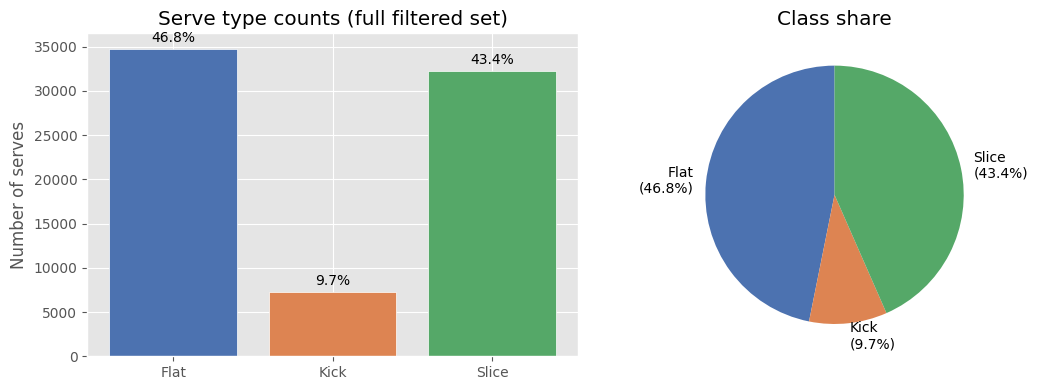

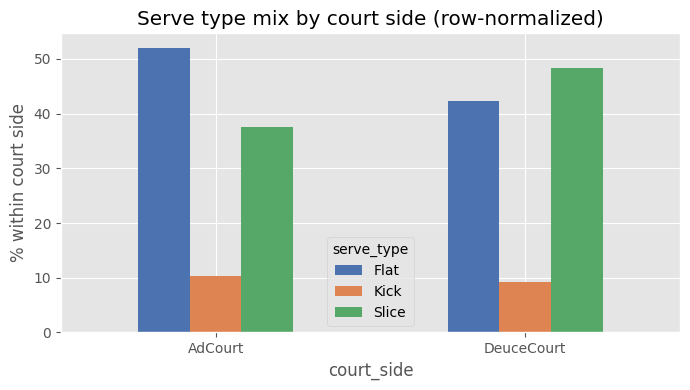

In [41]:
counts = analysis_df["serve_type"].value_counts().reindex(["Flat", "Kick", "Slice"])
pct = (counts / counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = [PALETTE[c] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of serves")
axes[0].set_title("Serve type counts (full filtered set)")
for i, (name, n) in enumerate(counts.items()):
    axes[0].text(i, n + 800, f"{pct[name]:.1f}%", ha="center", fontsize=10)

axes[1].pie(counts.values, labels=[f"{k}\n({pct[k]:.1f}%)" for k in counts.index],
            colors=colors, autopct="", startangle=90)
axes[1].set_title("Class share")

plt.tight_layout()
plt.show()

# Court side × serve type
ct = pd.crosstab(analysis_df["court_side"], analysis_df["serve_type"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind="bar", ax=ax, color=[PALETTE[c] for c in ct.columns], rot=0)
ax.set_ylabel("% within court side")
ax.set_title("Serve type mix by court side (row-normalized)")
ax.legend(title="serve_type")
plt.tight_layout()
plt.show()

### 2. Trajectory physics by serve type
Kick serves often show higher net clearance and different lateral paths. These plots show **raw** Hawk-Eye coordinates (after Ad-court x-mirror).

/tmp/ipykernel_470522/3048455690.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=["Flat", "Kick", "Slice"], patch_artist=True)
/tmp/ipykernel_470522/3048455690.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=["Flat", "Kick", "Slice"], patch_artist=True)
/tmp/ipykernel_470522/3048455690.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_type, labels=["Flat", "Kick", "Slice"], patch_artist=True)
/tmp/ipykernel_470522/3048455690.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

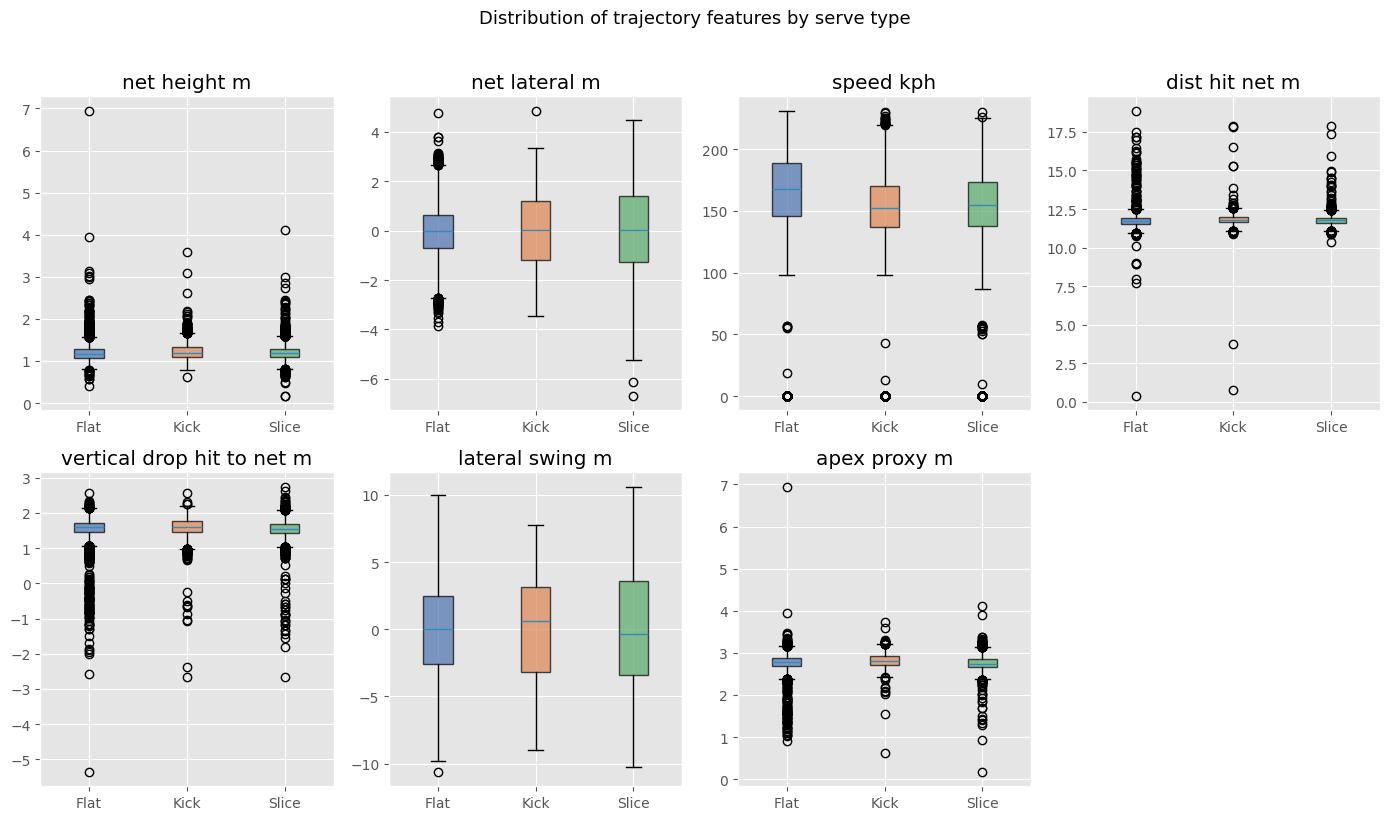

In [42]:
FEATURE_COLS = [
    "net_height_m",
    "net_lateral_m",
    "speed_kph",
    "dist_hit_net_m",
    "vertical_drop_hit_to_net_m",
    "lateral_swing_m",
    "apex_proxy_m",
]

plot_df = analysis_df.dropna(subset=FEATURE_COLS[:3])  # speed optional for some rows

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, FEATURE_COLS):
    sub = analysis_df.dropna(subset=[col])
    data_by_type = [sub.loc[sub["serve_type"] == st, col].values for st in ["Flat", "Kick", "Slice"]]
    bp = ax.boxplot(data_by_type, labels=["Flat", "Kick", "Slice"], patch_artist=True)
    for patch, st in zip(bp["boxes"], ["Flat", "Kick", "Slice"]):
        patch.set_facecolor(PALETTE[st])
        patch.set_alpha(0.7)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")

axes[-1].axis("off")
plt.suptitle("Distribution of trajectory features by serve type", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

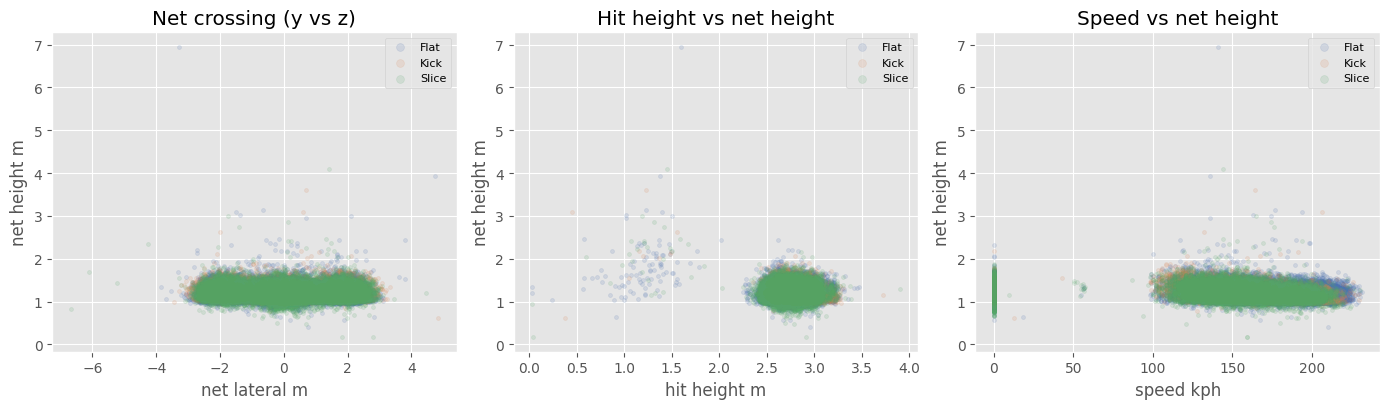

In [43]:
# 2D views: net crossing (most relevant for Kick vs Flat)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

pairs = [
    ("net_lateral_m", "net_height_m", "Net crossing (y vs z)"),
    ("hit_height_m", "net_height_m", "Hit height vs net height"),
    ("speed_kph", "net_height_m", "Speed vs net height"),
]

for ax, (xcol, ycol, title) in zip(axes, pairs):
    sub = analysis_df.dropna(subset=[xcol, ycol])
    for st in ["Flat", "Kick", "Slice"]:
        m = sub["serve_type"] == st
        ax.scatter(
            sub.loc[m, xcol], sub.loc[m, ycol],
            alpha=0.15, s=8, c=PALETTE[st], label=st,
        )
    ax.set_xlabel(xcol.replace("_", " "))
    ax.set_ylabel(ycol.replace("_", " "))
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

### 3. Correlations & mean serve paths

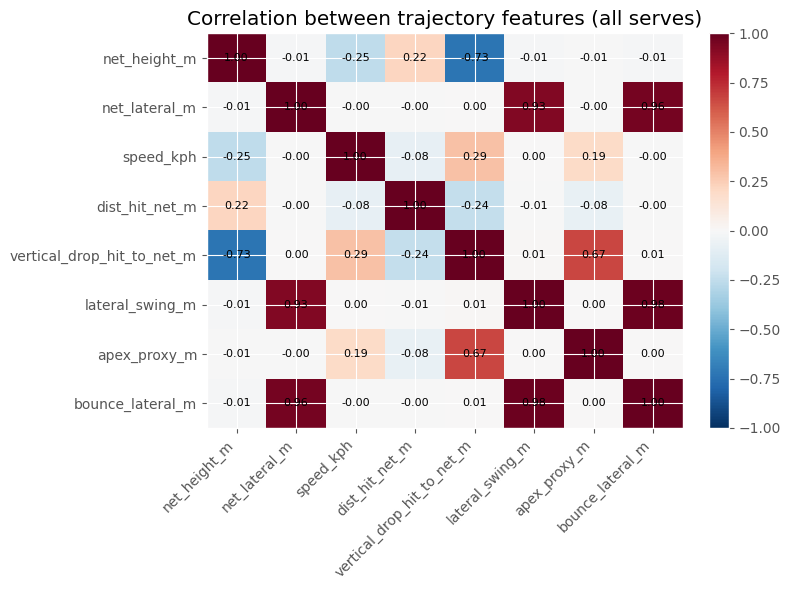

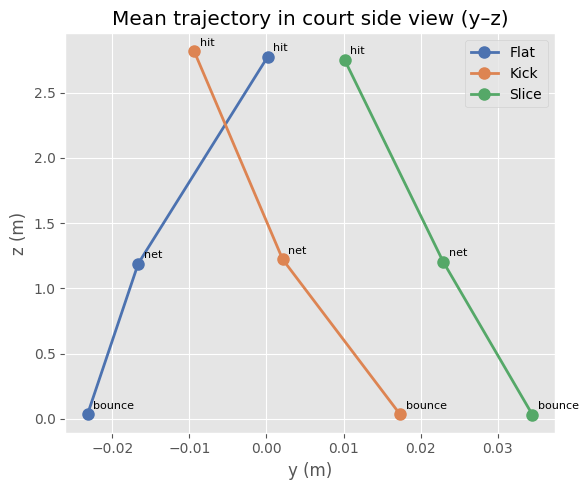

In [44]:
corr_cols = FEATURE_COLS + ["bounce_lateral_m"]
corr_df = analysis_df[corr_cols + ["serve_type"]].copy()
corr_num = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_num.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_num.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Correlation between trajectory features (all serves)")
plt.tight_layout()
plt.show()

# Mean path in side view (y vs z): hit → net → bounce
def mean_path(df, serve_type):
    sub = df[df["serve_type"] == serve_type]
    ys = np.stack([
        sub["y_ball_serve_impact"].values,
        sub["y_net_serve"].values,
        sub["y_serve_bounce"].values,
    ], axis=1)
    zs = np.stack([
        sub["z_ball_serve_impact"].values,
        sub["z_net_serve"].values,
        sub["z_serve_bounce"].values,
    ], axis=1)
    return ys.mean(axis=0), zs.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
for st in ["Flat", "Kick", "Slice"]:
    y_path, z_path = mean_path(analysis_df, st)
    ax.plot(y_path, z_path, "o-", color=PALETTE[st], lw=2, ms=8, label=st)
    for i, name in enumerate(["hit", "net", "bounce"]):
        ax.annotate(name, (y_path[i], z_path[i]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("y (m)")
ax.set_ylabel("z (m)")
ax.set_title("Mean trajectory in court side view (y–z)")
ax.legend()
plt.tight_layout()
plt.show()

### 4. Serve speed & direction (when available)

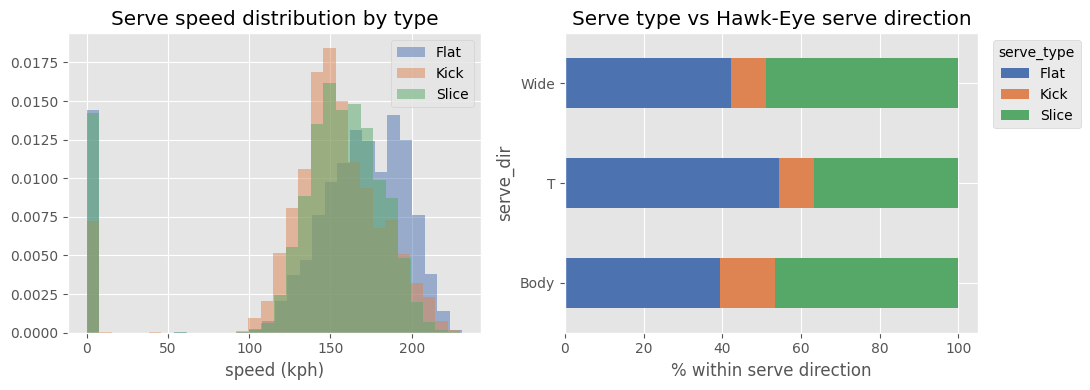

In [45]:
speed_df = analysis_df.dropna(subset=["speed_kph"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for st in ["Flat", "Kick", "Slice"]:
    vals = speed_df.loc[speed_df["serve_type"] == st, "speed_kph"]
    axes[0].hist(vals, bins=30, density=True, alpha=0.5, label=st, color=PALETTE[st])
axes[0].legend()
axes[0].set_title("Serve speed distribution by type")
axes[0].set_xlabel("speed (kph)")

if "serve_dir" in analysis_df.columns:
    dir_ct = pd.crosstab(analysis_df["serve_dir"], analysis_df["serve_type"])
    dir_pct = dir_ct.div(dir_ct.sum(axis=1), axis=0) * 100
    dir_pct.plot(kind="barh", stacked=True, ax=axes[1],
                 color=[PALETTE[c] for c in dir_pct.columns])
    axes[1].set_xlabel("% within serve direction")
    axes[1].set_title("Serve type vs Hawk-Eye serve direction")
    axes[1].legend(title="serve_type", bbox_to_anchor=(1.02, 1))
else:
    axes[1].text(0.5, 0.5, "serve_dir not in data", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5. Model errors (test set)
Uses `serve_lstm_best.pt` if present; otherwise run the test cell in Part 2 first.

              precision    recall  f1-score   support

        Flat       0.80      0.66      0.72      3477
        Kick       0.32      0.57      0.41       724
       Slice       0.71      0.72      0.71      3222

    accuracy                           0.68      7423
   macro avg       0.61      0.65      0.62      7423
weighted avg       0.71      0.68      0.69      7423



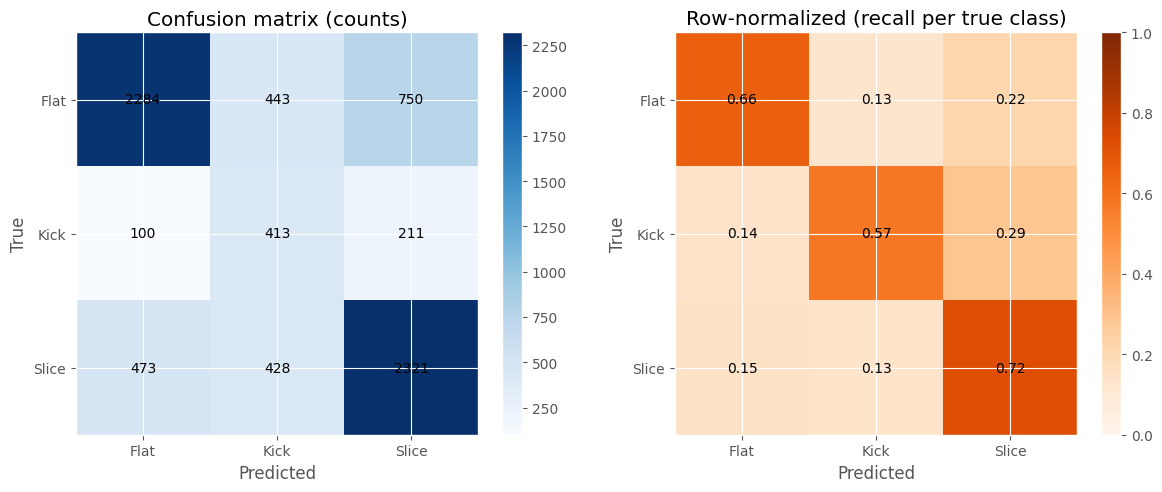

False Kick predictions: 871  |  Missed Kicks: 311


/tmp/ipykernel_470522/252347809.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_groups.values(), labels=plot_groups.keys())
/tmp/ipykernel_470522/252347809.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_groups.values(), labels=plot_groups.keys())


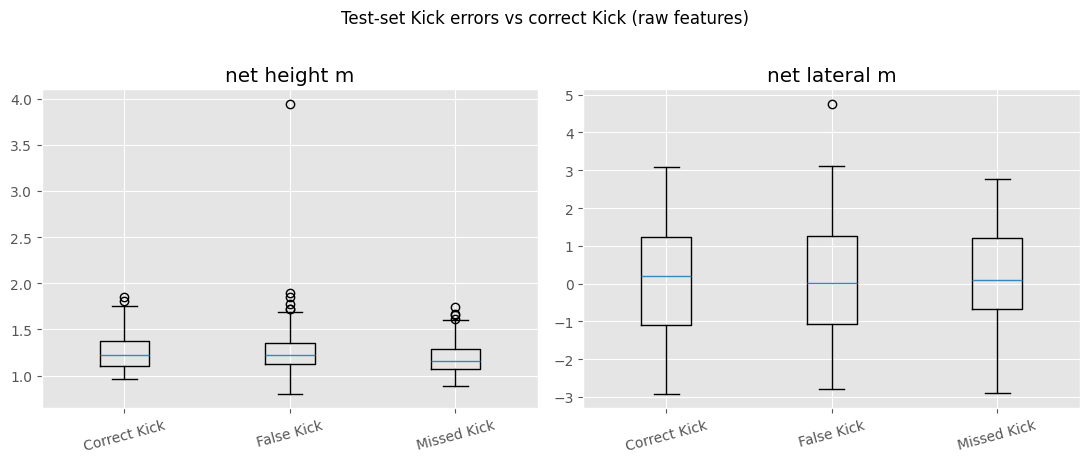

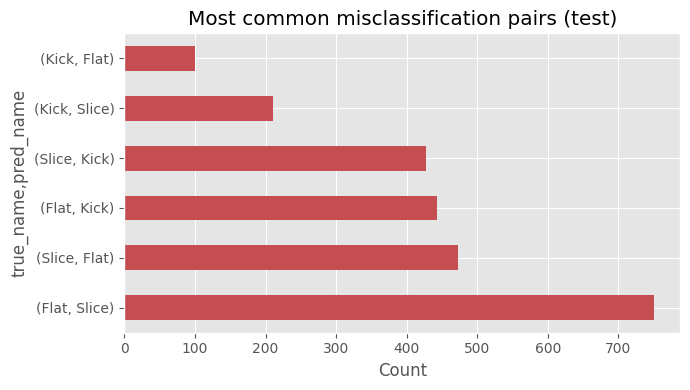

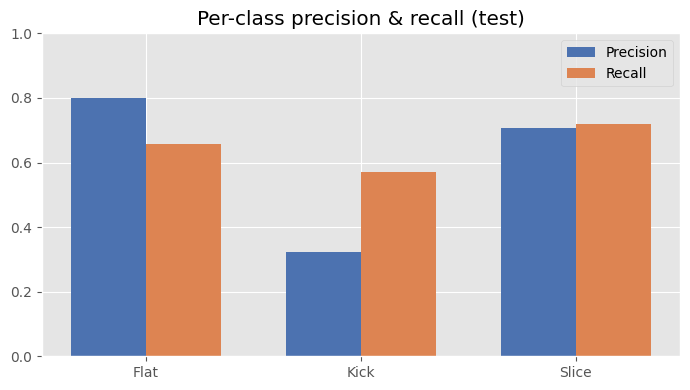

In [46]:
from torch.utils.data import DataLoader, TensorDataset

ckpt_path = Path("serve_lstm_best.pt")
if not HAS_TORCH or not ckpt_path.exists():
    print("Skip model analysis: need PyTorch and serve_lstm_best.pt")
else:
    import importlib
    import model as model_module
    import train as train_module
    importlib.reload(model_module)
    importlib.reload(train_module)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_test_t, y_test_t = torch.load("test_data.pt", weights_only=True)

    ckpt = torch.load(ckpt_path, weights_only=True, map_location=device)
    params = ckpt.get("params", {})

    model = model_module.build_model(
        hidden_size=int(params.get("hidden_size", 128)),
        num_layers=int(params.get("num_layers", 2)),
        dropout=float(params.get("dropout", 0.2)),
        bidirectional=bool(params.get("bidirectional", False)),
        use_layernorm=bool(params.get("use_layernorm", False)),
        device=device,
    )
    model.load_state_dict(ckpt["model_state_dict"])

    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=512, shuffle=False)
    y_pred_t, y_true_t = train_module.predict_all(model, test_loader, device)
    y_pred = y_pred_t.numpy()
    y_true = y_true_t.numpy()

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    def _plot_cm(ax, matrix, fmt, title, cmap, vmin=None, vmax=None):
        im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES)
        ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                txt = f"{int(val)}" if fmt == "d" else f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center", color="black")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046)

    _plot_cm(axes[0], cm, "d", "Confusion matrix (counts)", "Blues")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    _plot_cm(axes[1], cm_norm, ".2f", "Row-normalized (recall per true class)", "Oranges", 0, 1)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Row-normalized (recall per true class)")

    plt.tight_layout()
    plt.show()

    err = test_df.copy()
    err["y_true"] = y_true
    err["y_pred"] = y_pred
    err["true_name"] = err["y_true"].map(INV_LABEL)
    err["pred_name"] = err["y_pred"].map(INV_LABEL)
    err["correct"] = err["y_true"] == err["y_pred"]

    false_kick = err[(err["y_pred"] == 1) & (err["y_true"] != 1)]
    missed_kick = err[(err["y_true"] == 1) & (err["y_pred"] != 1)]
    print(f"False Kick predictions: {len(false_kick)}  |  Missed Kicks: {len(missed_kick)}")

    # Physics of errors vs correct Kick
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    groups = {
        "Correct Kick": err[(err["y_true"] == 1) & (err["y_pred"] == 1)],
        "False Kick": false_kick,
        "Missed Kick": missed_kick,
    }
    for ax, col in zip(axes, ["net_height_m", "net_lateral_m"]):
        plot_groups = {k: v[col].dropna() for k, v in groups.items() if len(v)}
        if plot_groups:
            ax.boxplot(plot_groups.values(), labels=plot_groups.keys())
        ax.set_title(col.replace("_", " "))
        ax.tick_params(axis="x", rotation=15)
    plt.suptitle("Test-set Kick errors vs correct Kick (raw features)", y=1.02)
    plt.tight_layout()
    plt.show()

    # Top confusion pairs (excluding diagonal)
    err_pairs = err[~err["correct"]].groupby(["true_name", "pred_name"]).size().sort_values(ascending=False).head(8)
    fig, ax = plt.subplots(figsize=(7, 4))
    err_pairs.plot(kind="barh", ax=ax, color="#C44E52")
    ax.set_xlabel("Count")
    ax.set_title("Most common misclassification pairs (test)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    types = list(CLASS_NAMES)
    prec = []
    rec = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]
        prec.append(tp / cm[:, i].sum() if cm[:, i].sum() else 0)
        rec.append(tp / cm[i, :].sum() if cm[i, :].sum() else 0)
    x = np.arange(NUM_CLASSES)
    w = 0.35
    ax.bar(x - w/2, prec, w, label="Precision", color="#4C72B0")
    ax.bar(x + w/2, rec, w, label="Recall", color="#DD8452")
    ax.set_xticks(x, types)
    ax.set_ylim(0, 1)
    ax.set_title("Per-class precision & recall (test)")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 6. Training curves (if `history` from Part 2 is in memory)

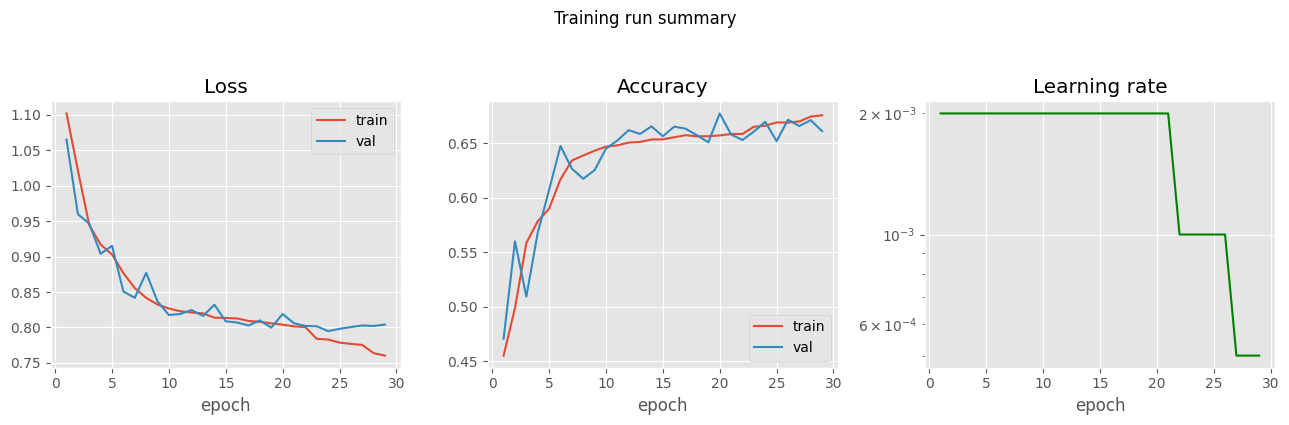

In [47]:
if "history" not in dir() or "train_loss" not in history:
    print("Run the final training cell first to plot learning curves.")
else:
    epochs_ran = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3 if "lr" in history and history["lr"] else 2, figsize=(13, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes[0].plot(epochs_ran, history["train_loss"], label="train")
    axes[0].plot(epochs_ran, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs_ran, history["train_acc"], label="train")
    axes[1].plot(epochs_ran, history["val_acc"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    if len(axes) > 2 and history.get("lr"):
        axes[2].plot(epochs_ran, history["lr"], color="green")
        axes[2].set_title("Learning rate")
        axes[2].set_xlabel("epoch")
        axes[2].set_yscale("log")

    plt.suptitle("Training run summary", y=1.05)
    plt.tight_layout()
    plt.show()